# Project Management Dashboard

**Authors:** Ryan Carney and Nikolas Rodriguez

**Course:** CS 188

**Date:** December 5, 2025

## Abstract

Managing dependencies across multiple repositories in software organizations presents significant coordination challenges, which are then amplified when considering release versions and inter-project dependencies. As such, the fireforce6 system required a systematic approach to dependency visualization and management, as this system is composed of many small constituent systems. This paper presents a Project Management Dashboard system that combines formal systems engineering methodology with practical GitHub App implementation to address this challenge, as well as provide more metadata about each repository such as hours logged.

Our solution uses the Ontological Modeling Language (OML) to formally model system requirements, capabilities, processes, entities, and operational scenarios following the Sierra Systems Engineering Method. We then use SPARQL to query our model and extract information, later visualizing this data through Jupyter notebooks with matplotlib and PlantUML visualizations.

Our implemented dashboard successfully delivers a fully functional web interface that provides real-time dependency visualization across all six FireForce6 repositories. Through organization-level GitHub App integration, the system actively fetches and displays current dependency relationships and version information, providing developers and project managers an overview of the fireforce6 system. Our evaluation demonstrates not only complete requirement traceability, but also a working production system that developers can immediately access and use for dependency management. 

## 1. Introduction

[Introduce the problem you're solving, why it matters, and what your solution is. Include:
- Problem statement
- Motivation
- Key contributions
- Paper organization]

## 2. Background & Related Work

This section establishes the foundation for our work and justifies why a new approach combining formal systems engineering with practical dependency management was necessary.

### Systems Engineering Approaches: MBSE, ConOps, and Semantic Modeling

**What exists**: Model-Based Systems Engineering (MBSE) is a prominent practice in System Engineering, motivated by the need to formalize models in order to avoid the ambiguity of natural language. As such, capturing the system in a living, formal document is a vital step of the systems engineering process. One such way of doing this is by first starting with a living ConOps document. The main benefit of these documents is that they can describe a system from the stakeholders perspectives, including the requirements, the related capabilities, and the different scenarios and entities involved. Further, all of this is done without implementation details, allowing for flexibility in the implementation while maintaining the concept of building the right system. 

Once a ConOps document has been established, one tool that can be used to convert this information from a document format to a true formal model is the Ontological Modeling Language (OML). OML provides a rigorous foundation for capturing the information that describes system concepts, their properties, and relationships. OML organizes knowledge into vocabularies (defining conceptual schemas) and descriptions (creating specific instances), enabling reusability and consistent modeling patterns. Lastly, once the system has been formalized with an OML model, system engineers may want to query the model, to be able to ask interesting questions about the system. One existing tool to accomplish this is SPARQL, an SQL-like query language, which provides powerful pattern-matching capabilities for querying graph-structured data. The results of the queries, stored as json objects, can then be used for other tasks such as visualization. 

**What are their limits**: Traditional MBSE tools are not designed for software-specific challenges like multi-repository dependency management, and therefore do not natively integrate with platforms like GitHub. Further, while these tools may allow artifacts like a specific package release as an entity, there is no genuine understanding of what that artifact actually is. 

As previously mentioned, ConOps documents do not contain specific details about the implementation. So, for the software side of the project management system, the ConOps document wouldn’t have any mechanism linking it to the specific code or repository. Further, because the ConOps document lives separate from our actual technical artifacts, changes in one area must also be made in the other, which can create some redundancy in the work being done.

Lastly, as previously mentioned, the results of the SPARQL queries are JSON objects. While these objects may be easily machine parsable, they are not the most readable for humans. This is especially true when the query is complex or returns lots of results. Therefore, in order for it to be effectively used at the scale of the fireforce6 project, it requires supplemental tools to help portray the results of the query.

**How we are different**: Our approach applies the MBSE rigor to the entirety of the project management environment system, including the software side. We maintain the formalism needed in a system like this with OML, which helps us bridge the gap between formal modeling and practical implementation. Further, the entirety of our OML model lives within our project management environment repository, which helps to ensure that our model remains central in our system and evolves alongside the actual implementation.

We first started by describing our system in its entirety within a ConOps document. Next, we formalized our ConOps document directly in the OML model, creating machine-readable representations of stakeholders, requirements, missions, capabilities, processes, and scenarios. In order to do so, we leveraged the Sierra Method repository, which allowed us to include these crucial building blocks in our own code. This allowed for traceability throughout the entire system, allowing us to objectively determine which processes implement a given capability, which capabilities satisfy a requirement, and which requirements a stakeholder expressed. 

Once our OML model was complete and pushed to our repository, we began to ask questions about our system with SPARQL. Our SPARQL queries extract project management insights (requirements traceability, capability dependencies, process allocations) from OML models and feed them into Jupyter notebooks for visualization. This addresses one of the major limitations of SPARQL previously mentioned, which is that the results are not easily human readable. In other words, we built and analyzed our system using a pipeline, starting from our ConOps documentation, to an OML Model, to SPARQL queries, to visualization with Python.

### Repository Management and Dependency Visualization

**What exists**: GitHub and its ecosystem provide tools for coordinating multi-repository projects. GitHub also provides pre-made “GitHub Apps”, installable to individual repositories or at the organizational level, along with the ability to custom-make these apps. At the package level, tools like Maven manage dependencies within individual projects using specification files. In order to keep related constituent systems together, GitHub allows their repositories to all be placed within a single organization, but this simply indicates that these subsystems are somehow related, providing no information about how they depend on each other.

In terms of software dependency visualization, different tools visualize software dependencies at different levels. Package managers provide tree views, showing transitive dependencies within a project. Architecture documentation tools like PlantUML and Mermaid can also be used manually to create diagrams.

**What are their limits**: Many existing dependency management tools operate primarily at the individual repository level and lack organization-wide visibility. Further, their ability to effectively visualize these dependencies is questionable. However, the more critical limitation is that existing tools don’t provide traceability from stakeholder needs through requirements to capabilities and implementation. Instead, they solely focus on technical dependencies without the systems engineering context of why certain architecture decisions were made or which stakeholder needs they serve. Another approach is to attempt to manually track the dependencies within a system. However, these methods are extremely prone to becoming stale, and don’t provide any way to programmatically analyze. 

The bottom line is that existing visualization tools operate at either too low a level (code/package dependencies within a single project) or require manual creation (architecture diagrams that can become outdated). They don't automatically discover dependencies across multiple repositories, don't connect visualizations to formal system models, and don't provide multiple stakeholder-specific views. A developer may need detailed technical dependency information while a project manager needs a high-level overview, and existing tools don't serve both audiences from a single underlying model.

**How we are different**: Our system is different because it provides organization-level dependency tracking and visualization across all six fireforce6 repositories while maintaining formal traceability back to stakeholder requirements. Rather than just showing technical dependencies, our OML model connects the dependency architecture to specific capabilities and requirements expressed by the stakeholders. In other words, we took a systems engineering perspective that transforms dependency management from a purely technical task into a traceable design decision that satisfies stakeholder needs.

We maintain the multi-repository structure that allows each subsystem to work independently while adding a formal systems engineering layer that doesn't exist in traditional multi-repo approaches. Our GitHub App provides automated data collection ensuring that the system always reflects current repository state rather than relying on manual updates. The OML model enables programmatic querying through SPARQL, allowing us to generate views like "all capabilities that depend on c1-authorization" or "all processes allocated to the dashboard entity" that would be difficult or impossible with static documentation.

Our visualizations are generated with python using the results fetched using the GitHub App. We provide visualizations which are aware of not only dependencies, but also other aspects of the constituent systems such as release versions and hours logged. Further, the color-coded component of our graph allows fellow system engineers to understand the state of the fireforce6 organization at a glance. Lastly, the most important piece is that our visualizations are not manually created, but are instead programmatically generated and make use of the GitHub app.


## 3. System Architecture & Design

This section presents the architecture of our project management dashboard system, demonstrating how our formal OML model integrates with the GitHub App and dependency visualization. The architecture spans three layers: the formal systems engineering model (OML vocabularies and SPARQL queries), the data collection layer (GitHub App with API integration), and the visualization layer (frontend dashboard). 

In [1]:
# Setup the environment for visualizations

import sys
sys.path.append('/mnt/project')
from utilities import dataframe, extract_id, todict, tolists, diagram, union
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import seaborn as sns
import networkx as nx
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set beautiful style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Define consistent color scheme
COLORS = {
    'stakeholder': '#FF6B6B',
    'requirement': '#4ECDC4',
    'capability': '#45B7D1',
    'mission': '#FFA07A',
    'entity': '#98D8C8',
    'process': '#C7CEEA',
    'dataflow': '#B7E4C7',
    'scenario': '#FFD93D'
}

print("Setup complete! Ready to visualize the system architecture.")

Setup complete! Ready to visualize the system architecture.


### Our OML Model - Choosing OML

We chose OML over alternative modeling approaches for three primary reasons. Firstly, the formal language of OMLS enables automated reasoning, that could easily be validated for consistency and integrated into the CI pipeline. Secondly, OML models are queryable via SPARQL. This allowed us to extract information about the model as JSON objects, which we could then use to make meaningful diagrams. Lastly, OML separates vocabularies and descriptions, allowing us to define reusable patterns (as well as include the sierra vocabularies) that can be instantiated for specific projects.

### Requirements and Stakeholder Analysis

Our system serves two distinct stakeholder groups, each with specific needs that drove our architectural decisions.

**Developers** work within individual subprojects and need visibility into how their repository dependencies relate to the broader fireforce6 organization. They require technical detail about specific dependency versions and compatibility, and need this information to be located in a central location.

**Project Managers** oversee all subprojects and need high-level strategic visibility into the dependency landscape. They must identify potential integration issues, understand which teams depend on which components, and communicate system status to leadership without necessarily understanding technical implementation details.

These stakeholder groups expressed three primary requirements:

**R1 (Visual Overview)**: The dashboard must provide a visual overview of the dependencies and current releases for each sub-project. Both developers and project managers need graphical representations rather than text-based dependency lists. 

**R2 (File Compatibility)**: The dashboard must be compatible with dependency specification files in each subproject's repository. We were aware of the fact that different groups may be using different technical stacks, but the fact remained that we needed to fetch data from each repository. This requirement led to our design decision to require a standardized YAML format used by teams to list their dependencies and hours logged.

**R3 (Up-to-Date Data)**: The dashboard must have up-to-date versions and dependencies displayed in its graph, both stakeholder groups would be negatively affected by stale documentation. This requirement justified our GitHub App approach, which programmatically fetches current data from repositories rather than relying on manual updates to spreadsheets or wiki pages.

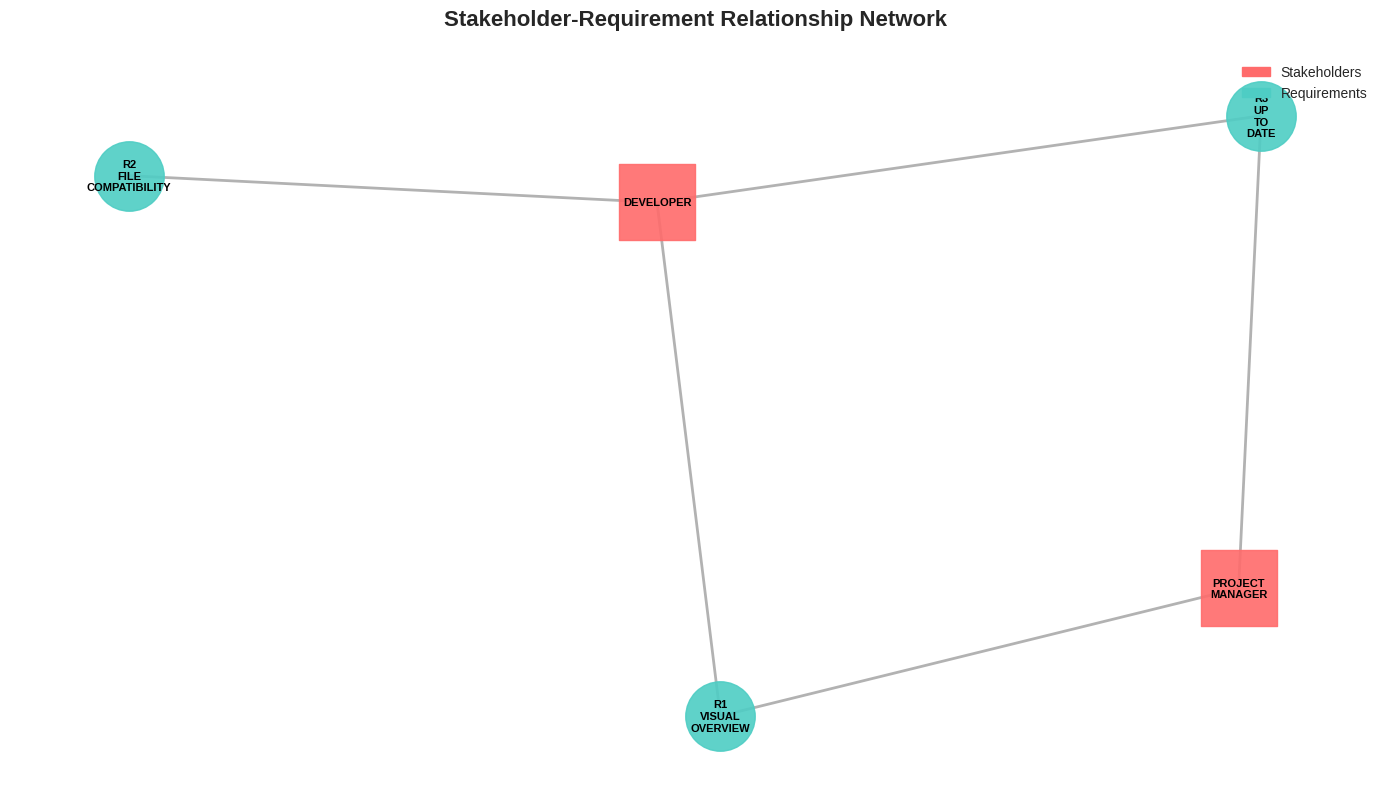

In [3]:
# Load stakeholders data
stakeholders_df = dataframe("stakeholders.json")
stakeholders_df['stakeholder_id'] = stakeholders_df['stakeholder'].apply(extract_id)

# Load requirements data
requirements_df = dataframe("requirements.json")
requirements_df['req_id'] = requirements_df['req'].apply(extract_id)
requirements_df['stakeholder_id'] = requirements_df['stakeholder_desc'].apply(
    lambda x: 'developer' if 'Developers' in x else 'project-manager'
)
unique_reqs = requirements_df.drop_duplicates(subset=['req_id'])[['req_id', 'req_desc']]

# Create requirement-stakeholder network graph
fig, ax = plt.subplots(figsize=(14, 8))
G = nx.Graph()

# Add nodes
for _, row in stakeholders_df.iterrows():
    G.add_node(row['stakeholder_id'], node_type='stakeholder')
for _, row in unique_reqs.iterrows():
    G.add_node(row['req_id'], node_type='requirement')

# Add edges
for _, row in requirements_df.iterrows():
    G.add_edge(row['stakeholder_id'], row['req_id'])

# Layout
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Draw nodes
stakeholder_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'stakeholder']
requirement_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'requirement']

nx.draw_networkx_nodes(G, pos, nodelist=stakeholder_nodes, 
                       node_color=COLORS['stakeholder'], 
                       node_size=3000, 
                       alpha=0.9, 
                       node_shape='s',
                       ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=requirement_nodes, 
                       node_color=COLORS['requirement'], 
                       node_size=2500, 
                       alpha=0.9,
                       ax=ax)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='gray', width=2, alpha=0.6, ax=ax)

# Draw labels
labels = {n: n.replace('-', '\n').upper() for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold', ax=ax)

ax.set_title('Stakeholder-Requirement Relationship Network', 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

# Add legend
stakeholder_patch = mpatches.Patch(color=COLORS['stakeholder'], label='Stakeholders')
requirement_patch = mpatches.Patch(color=COLORS['requirement'], label='Requirements')
ax.legend(handles=[stakeholder_patch, requirement_patch], loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

### Missions and Capabilities

From these requirements, we derived two missions that capture the high-level operational goals:

**M1 (At-a-Glance Overview)**: Provide clear visuals displaying project connections and dependencies across the entire organization. This mission prioritizes information density and clarity. In other words, users should understand the dependency landscape within seconds of viewing the dashboard.

**M2 (Easy Integration)**: Enable access to files in subproject repositories without complex setup or manual configuration. This mission prioritizes automation and minimal requirements placed upon the other groups. The system should work at the organization level without requiring each team to perform installation steps.

These missions decompose into three operational capabilities:

**C1 (Authorization)**: The server must gain authorization from the GitHub App to access repository data. This capability directly supports M2 by handling authentication complexity transparently. The capability requires interaction between the Dashboard entity and the GitHub App entity.

**C2 (Fetch Capability)**: The server must fetch data from each subproject repository to obtain the current version and dependencies. This capability supports both M2 (by automating data collection) and R3 (by ensuring fresh data). It depends on C1 (can't fetch without authorization) and involves the GitHub App, Dashboard, and all subproject repository entities.

**C3 (Dashboard Display)**: The dashboard must take fetched dependencies and display them in a graph format. This capability directly satisfies R1 (visual overview) and M1 (at-a-glance). It depends on C2 (can't display data that hasn't been fetched) and involves only the Dashboard entity.

The capability dependency structure reveals a clear architectural flow: authorization enables fetching, which enables display. This linear dependency chain simplified our implementation by eliminating circular dependencies and establishing clear module boundaries.


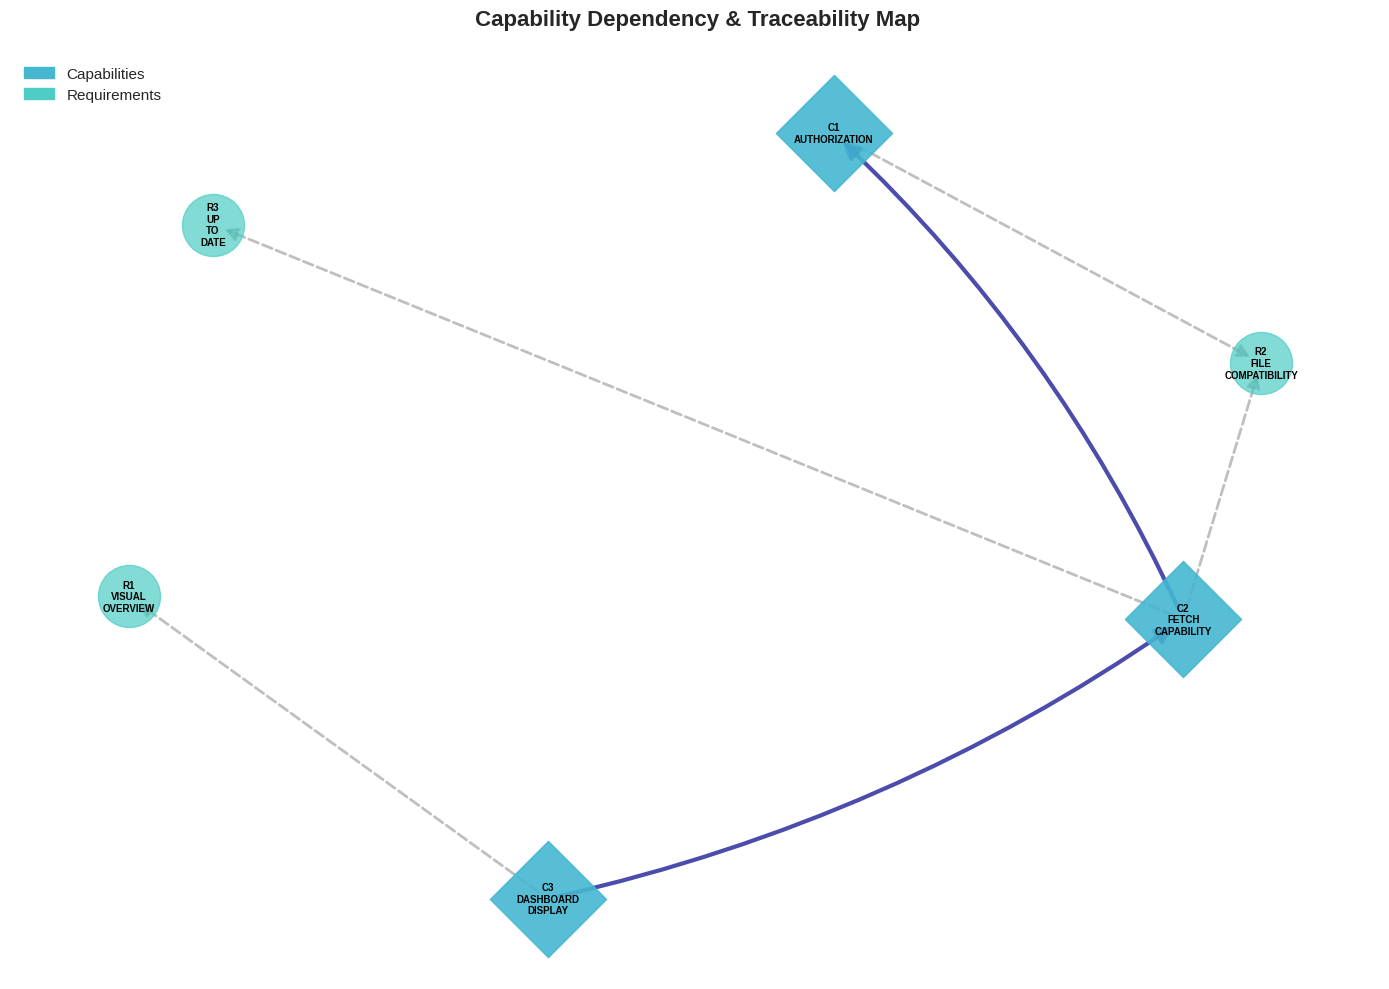

In [4]:
# Load capabilities data
capabilities_df = dataframe("capabilities.json")
capabilities_df['cap_id'] = capabilities_df['cap'].apply(extract_id)
capabilities_df['req_id'] = capabilities_df['req'].apply(extract_id) if 'req' in capabilities_df.columns else None

# Separate capabilities and missions
caps_only = capabilities_df[capabilities_df['cap_id'].str.startswith('c', na=False)].copy()
missions_only = capabilities_df[capabilities_df['cap_id'].str.startswith('m', na=False)].copy()

# Define capability dependencies manually (from capabilities.oml)
cap_dependencies = [
    ('c2-fetch-capability', 'c1-authorization'),
    ('c3-dashboard-display', 'c2-fetch-capability')
]

# Create directed graph
fig, ax = plt.subplots(figsize=(14, 10))

G = nx.DiGraph()

# Add capability nodes
for _, row in caps_only.drop_duplicates(subset=['cap_id']).iterrows():
    G.add_node(row['cap_id'], node_type='capability', desc=row['cap_desc'])

# Add requirement nodes
for _, row in unique_reqs.iterrows():
    G.add_node(row['req_id'], node_type='requirement', desc=row['req_desc'])

# Add edges: capabilities -> requirements (derivation)
for _, row in caps_only.iterrows():
    if pd.notna(row['req_id']):
        G.add_edge(row['cap_id'], row['req_id'], edge_type='derives')

# Add edges: capability dependencies
for src, tgt in cap_dependencies:
    G.add_edge(src, tgt, edge_type='requires')

# Hierarchical layout
pos = nx.spring_layout(G, k=3, iterations=50, seed=42)

# Separate node types
capability_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'capability']
requirement_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'requirement']

# Draw requirement nodes
nx.draw_networkx_nodes(G, pos, nodelist=requirement_nodes,
                       node_color=COLORS['requirement'],
                       node_size=2000,
                       alpha=0.7,
                       node_shape='o',
                       ax=ax)

# Draw capability nodes
nx.draw_networkx_nodes(G, pos, nodelist=capability_nodes,
                       node_color=COLORS['capability'],
                       node_size=3500,
                       alpha=0.9,
                       node_shape='D',
                       ax=ax)

# Draw edges with different styles
derives_edges = [(u, v) for u, v, d in G.edges(data=True) if d['edge_type'] == 'derives']
requires_edges = [(u, v) for u, v, d in G.edges(data=True) if d['edge_type'] == 'requires']

nx.draw_networkx_edges(G, pos, edgelist=derives_edges,
                       edge_color='gray',
                       style='dashed',
                       width=2,
                       alpha=0.5,
                       arrows=True,
                       arrowsize=20,
                       ax=ax)

nx.draw_networkx_edges(G, pos, edgelist=requires_edges,
                       edge_color='darkblue',
                       style='solid',
                       width=3,
                       alpha=0.7,
                       arrows=True,
                       arrowsize=25,
                       connectionstyle='arc3,rad=0.1',
                       ax=ax)

# Draw labels
labels = {n: n.replace('-', '\n').upper() for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=7, font_weight='bold', ax=ax)

ax.set_title(' Capability Dependency & Traceability Map', 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

# Enhanced legend
legend_elements = [
    mpatches.Patch(color=COLORS['capability'], label='Capabilities'),
    mpatches.Patch(color=COLORS['requirement'], label='Requirements'),
    mpatches.FancyArrow(0, 0, 1, 0, width=0.3, color='darkblue', label='Requires'),
    mpatches.FancyArrow(0, 0, 1, 0, width=0.3, color='gray', linestyle='dashed', label='Derived From')
]
ax.legend(handles=legend_elements[:2], loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

### System Entities and Entity Allocation

Our system architecture comprises five primary entities, each with specific responsibilities:

The **GitHub Organization** represents the fireforce6 organization container. While not directly involved in any capability (no active behavior), it contextualizes the system. The repositories exist within this organizational boundary, and the GitHub App is installed at this level rather than individual repository level.

The **GitHub App** provides API access and authorization services. This entity is involved in C1 (Authorization) and C2 (Fetch Capability). The GitHub App authenticates itself to GitHub using JWT-signed requests, then provides installation tokens to the Dashboard. It also mediates all repository access, as the Dashboard doesn't directly connect to repositories, it requests data through the GitHub App's API layer.

We used a GitHub App in our system because GitHub Apps provide organization-level installation, more granular permissions, and better security through short-lived installation tokens. Personal access tokens are tied to individual users (problematic when that person leaves the organization) and have broader permissions than necessary. OAuth Apps require user interaction for authorization, making automation difficult.

The **Dashboard** serves as the primary user-facing entity. It's involved in all three capabilities (C1, C2, C3). The Dashboard orchestrates the overall workflow: it requests authorization, uses that authorization to fetch dependency data, and presents visualizations to users. 

The **Subproject Repositories** represent the source repositories containing dependency specification files. These entities are involved in C2 (Fetch Capability). They respond to API requests by providing file contents. Each of the six fireforce6 repositories is a concrete instance.

The reason that we chose to model the repositories each as invidual entities is that although repositories are data stores, modeling them as entities that respond to API requests (rather than passive data) better captures the system dynamics. Repositories have permissions, they can deny access, they contain or lack certain files. All of these aspects are entity behaviors, not just data attributes.

The entity allocation reveals the Dashboard as the integration point. It's the only entity involved in all capabilities and has the most allocated activities. This centralization simplifies the architecture by creating a single coordinator, which is then made accessible to the stakeholders.


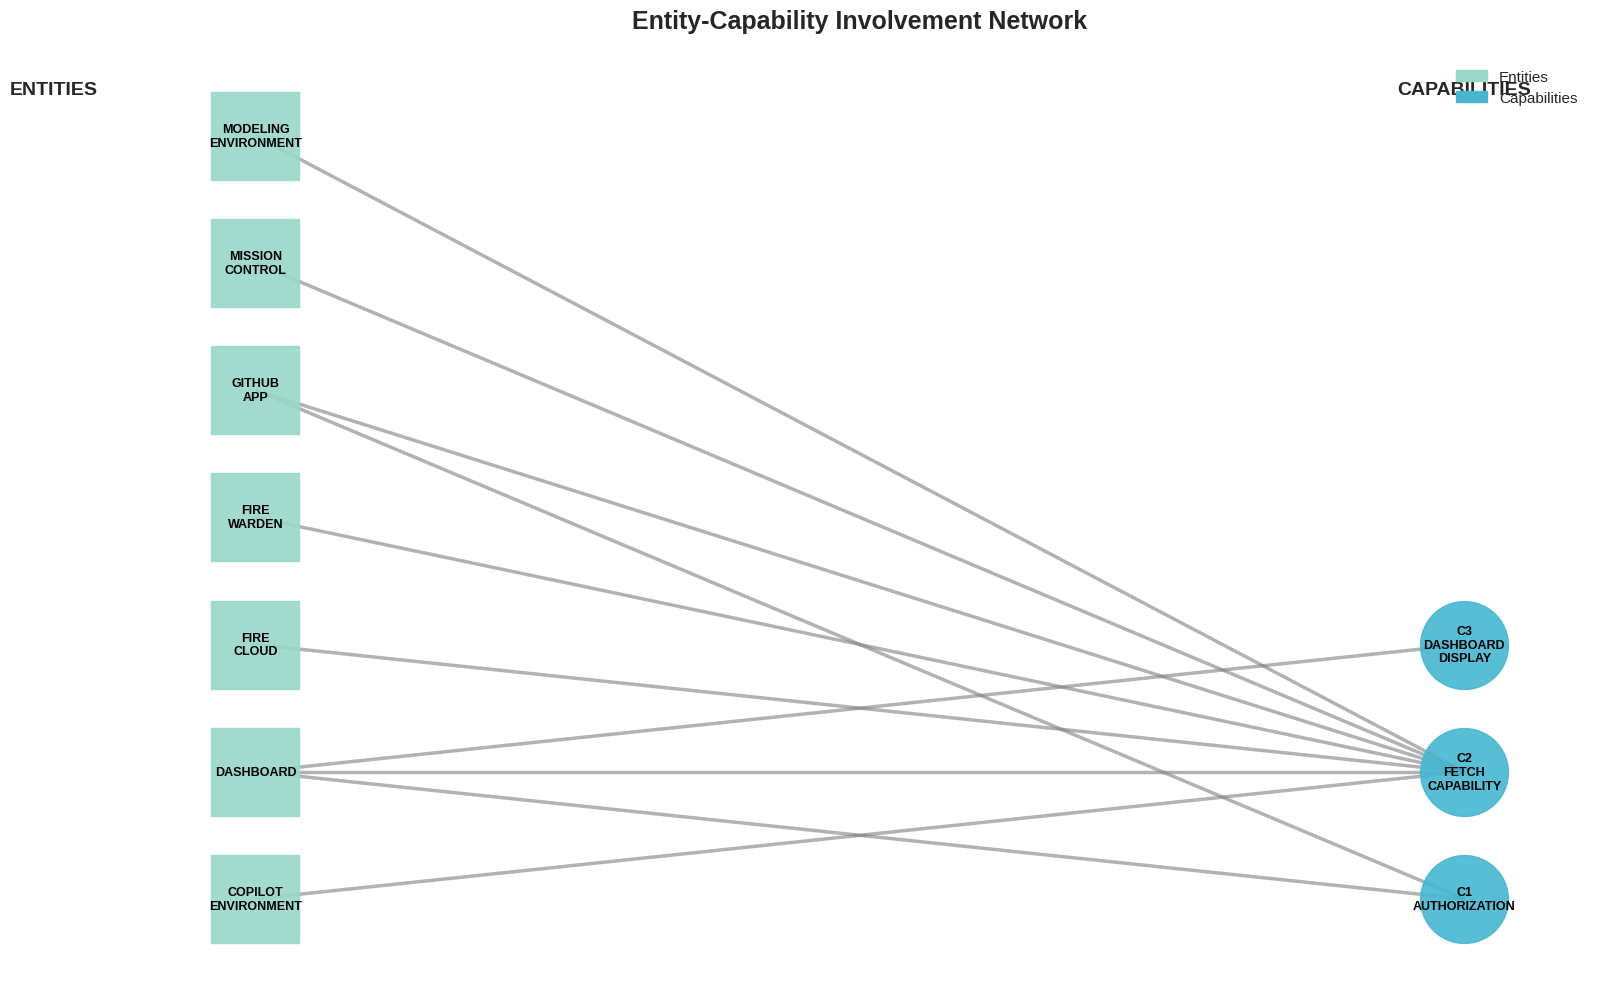

In [8]:
# Load entities and capabilities data
entities_df = dataframe("entities.json")
entities_df['entity_id'] = entities_df['entity'].apply(extract_id)
entities_df['cap_id'] = entities_df['capability'].apply(lambda x: extract_id(x) if pd.notna(x) else None)

capabilities_df = dataframe("capabilities.json")
capabilities_df['cap_id'] = capabilities_df['cap'].apply(extract_id)

# Filter to only actual capabilities (not missions)
capabilities_df = capabilities_df[capabilities_df['cap_id'].str.startswith('c', na=False)]
entities_df = entities_df[entities_df['cap_id'].notna()]

# Create entity-capability involvement network graph
fig, ax = plt.subplots(figsize=(16, 10))
G = nx.Graph()

# Add nodes
unique_entities = entities_df.drop_duplicates(subset=['entity_id'])[['entity_id', 'entity_desc']]
for _, row in unique_entities.iterrows():
    G.add_node(row['entity_id'], node_type='entity', desc=row['entity_desc'])

unique_capabilities = capabilities_df.drop_duplicates(subset=['cap_id'])[['cap_id', 'cap_desc']]
for _, row in unique_capabilities.iterrows():
    G.add_node(row['cap_id'], node_type='capability', desc=row['cap_desc'])

# Add edges (involvement relationships)
for _, row in entities_df.iterrows():
    if pd.notna(row['cap_id']):
        G.add_edge(row['entity_id'], row['cap_id'])

# Create bipartite layout
entity_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'entity']
capability_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'capability']

# Position entities on the left, capabilities on the right
pos = {}
entity_y_spacing = 1.5 if len(entity_nodes) > 1 else 1
cap_y_spacing = 1.5 if len(capability_nodes) > 1 else 1

for i, node in enumerate(entity_nodes):
    pos[node] = (0, i * entity_y_spacing)

for i, node in enumerate(capability_nodes):
    pos[node] = (3, i * cap_y_spacing)

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=entity_nodes, 
                       node_color=COLORS['entity'], 
                       node_size=4000, 
                       alpha=0.9, 
                       node_shape='s',
                       ax=ax)

nx.draw_networkx_nodes(G, pos, nodelist=capability_nodes, 
                       node_color=COLORS['capability'], 
                       node_size=4000, 
                       alpha=0.9,
                       ax=ax)

# Draw edges with varying thickness based on number of connections
nx.draw_networkx_edges(G, pos, edge_color='gray', width=2.5, alpha=0.6, ax=ax)

# Draw labels
entity_labels = {n: n.replace('-', '\n').upper() for n in entity_nodes}
capability_labels = {n: n.replace('-', '\n').upper() for n in capability_nodes}

nx.draw_networkx_labels(G, pos, entity_labels, font_size=9, font_weight='bold', ax=ax)
nx.draw_networkx_labels(G, pos, capability_labels, font_size=9, font_weight='bold', ax=ax)

ax.set_title('Entity-Capability Involvement Network', 
             fontsize=18, fontweight='bold', pad=20)
ax.axis('off')

# Add legend
entity_patch = mpatches.Patch(color=COLORS['entity'], label='Entities')
capability_patch = mpatches.Patch(color=COLORS['capability'], label='Capabilities')
ax.legend(handles=[entity_patch, capability_patch], loc='upper right', fontsize=11)

# Add section labels
ax.text(-0.5, max([p[1] for p in pos.values()]) + 0.5, 'ENTITIES', 
        fontsize=14, fontweight='bold', ha='center')
ax.text(3, max([p[1] for p in pos.values()]) + 0.5, 'CAPABILITIES', 
        fontsize=14, fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

### Process Architecture

Our system implements three core processes, each describing one of the three capabilities.

**Process 1: Get GitHub App Installation Token (Describes C1: Authorization)**

This process establishes authentication that enables all subsequent repository access.

**Activities**:
- **A1: Request Token** - Dashboard backend initiates the authentication flow by requesting an installation token from the GitHub App.
- **A2: Authenticate App** - GitHub App verifies its identity using JWT signed with its private key, then requests an installation token from GitHub's API.
- **A3: Receive Token** - Dashboard receives and stores the installation token for use in subsequent API requests.

There were a few reasons for using JWT authentication. Firstly, this is the native authentication system that GitHub has in place for its GitHub Apps. The motivation beyond the 2-step authentication is to increase security. Further, the JWT expires after 10 minutes, and the installation token expires after 1 hour, providing extra security by using short-lived credentials. 

**Process 2: Fetch Dependencies and Versions (Describes C2: Fetch Capability)**

This process retrieves current dependency information from each repository.

**Activities**:
- **A4: API Request To Subsystem Repo** - GitHub App interacts with the Subsystem repository via GitHub's REST API.
- **A5: Read  .settings.yaml File** - The Repository provides its dependency specification file contents.
- **A6: Fetch Subsystem Release Version** - Dashboard extracts the release version information from the result of the API call.

We make reading the .settings.yaml file a single activity because while the reading of this file is needed to obtain various pieces of data (dependencies and hours logged), we consider this a single activity since all data lives within a single file. Further, this allows for more pieces of metadata to be included in this file in the future, while maintaining a consistent model.

**Process 3: Display Dashboard (Describes C3: Dashboard Display)**

This process transforms the fetched data from the API call into user-facing visualizations.

Activities:
- **A7: Aggregate Data** - Combine version and dependency information from all repositories into a unified data structure
- **A8: Build Graph** - Construct a dependency graph representation from the aggregated data
- **A9: Render Visualization** - Generate visual displays (graphs, tables) for user consumption

We created three separate activities instead of one "display" activity because this decomposition reflects the distinct computational phases of this process, which we eventually implemented in software. Further, this split allows for specific components to be related back to the stakeholder needs. For example, the rendering activity contains presentation logic that might vary by stakeholder (managers want high-level views, developers want detailed views). Separating these activities allows different implementations for each phase and enables testing at each boundary.

The three processes form a pipeline: P1 establishes authentication → P2 uses authentication to fetch data → P3 transforms data into visualizations. The installation token and dependencies are the key interface data items that connect the processes.


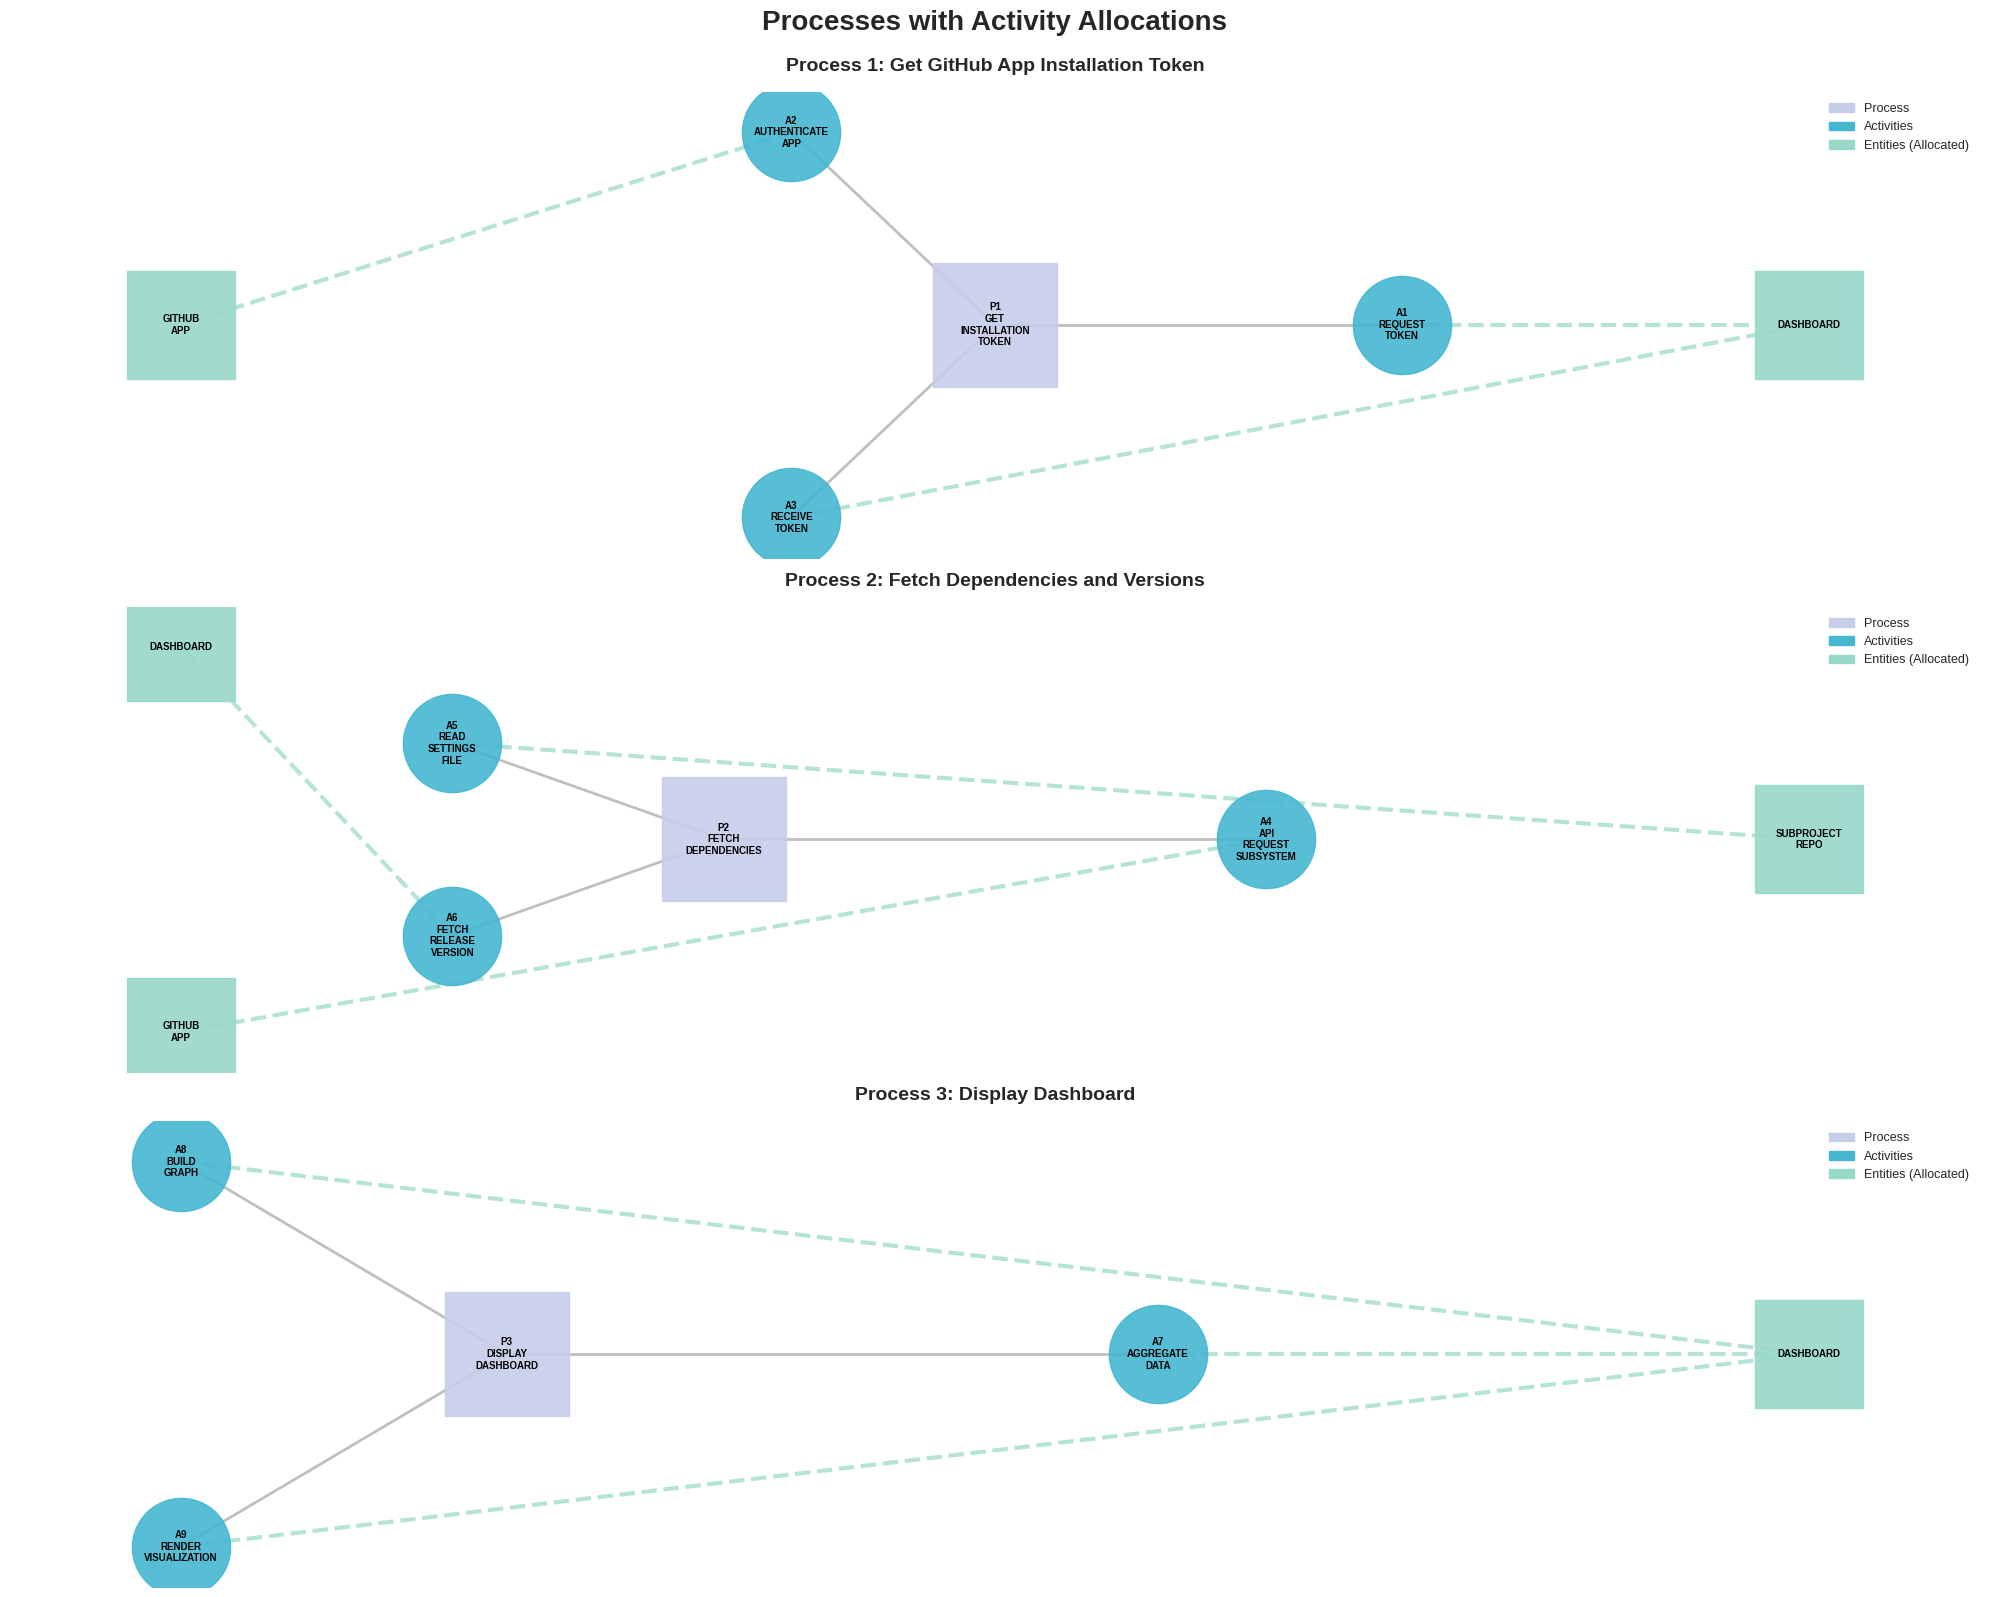

In [12]:
# Load processes data
processes_df = dataframe("processes.json")
processes_df['process_id'] = processes_df['process'].apply(extract_id)
processes_df['cap_id'] = processes_df['capability'].apply(lambda x: extract_id(x) if pd.notna(x) else None)

# Get unique processes
unique_processes = processes_df.drop_duplicates(subset=['process_id'])[['process_id', 'process_desc', 'cap_id']]

# Create a comprehensive process-activity diagram
fig, axes = plt.subplots(3, 1, figsize=(20, 16))
fig.suptitle('Processes with Activity Allocations', 
             fontsize=20, fontweight='bold', y=0.995)

process_list = ['p1-get-installation-token', 'p2-fetch-dependencies', 'p3-display-dashboard']
process_titles = [
    'Process 1: Get GitHub App Installation Token',
    'Process 2: Fetch Dependencies and Versions', 
    'Process 3: Display Dashboard'
]

# Define activities and their allocations based on modified architecture
process_activities = {
    'p1-get-installation-token': [
        ('a1-request-token', 'dashboard'),
        ('a2-authenticate-app', 'github-app'),
        ('a3-receive-token', 'dashboard')
    ],
    'p2-fetch-dependencies': [
        ('a4-api-request-subsystem', 'github-app'),
        ('a5-read-settings-file', 'subproject-repo'),
        ('a6-fetch-release-version', 'dashboard')
    ],
    'p3-display-dashboard': [
        ('a7-aggregate-data', 'dashboard'),
        ('a8-build-graph', 'dashboard'),
        ('a9-render-visualization', 'dashboard')
    ]
}

for idx, (process_id, process_title) in enumerate(zip(process_list, process_titles)):
    ax = axes[idx]
    
    # Get activities for this process
    activities = process_activities[process_id]
    
    # Create graph
    G = nx.Graph()
    
    # Add process node
    G.add_node(process_id, node_type='process')
    
    # Add activity and entity nodes
    entities_in_process = set()
    for activity, entity in activities:
        G.add_node(activity, node_type='activity')
        G.add_node(entity, node_type='entity')
        entities_in_process.add(entity)
        
        # Connect process to activity
        G.add_edge(process_id, activity)
        # Connect activity to entity (allocation)
        G.add_edge(activity, entity)
    
    # Create custom layout: process in center, activities around it, entities on the outside
    pos = {}
    
    # Process in center
    pos[process_id] = (0, 0)
    
    # Activities in a circle around process
    num_activities = len(activities)
    activity_radius = 2
    for i, (activity, _) in enumerate(activities):
        angle = 2 * np.pi * i / num_activities
        pos[activity] = (activity_radius * np.cos(angle), activity_radius * np.sin(angle))
    
    # Entities on the outside
    entity_list = list(entities_in_process)
    entity_radius = 4
    for i, entity in enumerate(entity_list):
        angle = 2 * np.pi * i / len(entity_list)
        pos[entity] = (entity_radius * np.cos(angle), entity_radius * np.sin(angle))
    
    # Draw process node
    nx.draw_networkx_nodes(G, pos, nodelist=[process_id],
                          node_color=COLORS['process'],
                          node_size=8000,
                          alpha=0.9,
                          node_shape='s',
                          ax=ax)
    
    # Draw activity nodes
    activity_nodes = [activity for activity, _ in activities]
    nx.draw_networkx_nodes(G, pos, nodelist=activity_nodes,
                          node_color=COLORS['capability'],
                          node_size=5000,
                          alpha=0.9,
                          node_shape='o',
                          ax=ax)
    
    # Draw entity nodes
    nx.draw_networkx_nodes(G, pos, nodelist=entity_list,
                          node_color=COLORS['entity'],
                          node_size=6000,
                          alpha=0.9,
                          node_shape='s',
                          ax=ax)
    
    # Draw edges
    # Process to activities
    process_edges = [(process_id, activity) for activity, _ in activities]
    nx.draw_networkx_edges(G, pos, edgelist=process_edges,
                          edge_color='gray',
                          width=2,
                          alpha=0.5,
                          ax=ax)
    
    # Activities to entities (allocations)
    allocation_edges = [(activity, entity) for activity, entity in activities]
    nx.draw_networkx_edges(G, pos, edgelist=allocation_edges,
                          edge_color=COLORS['entity'],
                          width=3,
                          alpha=0.7,
                          style='dashed',
                          ax=ax)
    
    # Draw labels
    labels = {n: n.replace('-', '\n').upper() for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, 
                           font_size=7, 
                           font_weight='bold',
                           ax=ax)
    
    ax.set_title(process_title, fontsize=14, fontweight='bold', pad=15)
    ax.axis('off')
    
    # Add legend
    process_patch = mpatches.Patch(color=COLORS['process'], label='Process')
    activity_patch = mpatches.Patch(color=COLORS['capability'], label='Activities')
    entity_patch = mpatches.Patch(color=COLORS['entity'], label='Entities (Allocated)')
    ax.legend(handles=[process_patch, activity_patch, entity_patch], 
             loc='upper right', 
             fontsize=9)

plt.tight_layout()
plt.show()

### Scenario Validation

Our scenario models validate that the architecture handles various operational conditions correctly, and are largely related to the health of the fireforce6 organization as a whole.

**S1: Acyclic Graph State** models normal operation when dependencies form a directed acyclic graph. The scenario shows the Dashboard sequentially fetching from the subproject repositories and successfully displaying the graph. This scenario validates that our basic pipeline (P1→P2→P3) works under ideal conditions.

**S2: Cyclic Graph State** models the situation where dependencies contain cycles (e.g., Repo A depends on Repo B, which depends on Repo A). The scenario shows the same fetch sequence but ends with an invalid graph state.

**S3: Data Exists with Read Access** models successful data retrieval when the GitHub App has proper permissions. This validates that our authorization model (C1/P1) correctly grants access.

**S4: Data Exists, No Read Access** models access denial when permissions are misconfigured. The scenario shows: GitHub App attempts request, followed by the repository denying access, and the dashboard displaying an invalid graph. This scenario validates that our architecture includes error handling for authentication failures, not just successful paths.

**S5: No Data Exists** models the situation where a repository lacks dependency specification files (e.g., a new repository not yet configured, or a repository using an unsupported build system). This validates that our system degrades gracefully rather than failing when data is missing.

We distinguish between “has access” and "no access" scenarios because these scenarios validate security requirements. The system must work correctly when authorized and fail gracefully when not authorized. Modeling both scenarios ensures we've considered the security implications and designed appropriate error handling.

The five scenarios collectively validate: normal operation (S1), exceptional data conditions (S2), successful authorization (S3), failed authorization (S4), and missing data (S5). By modeling these scenarios in OML and showing that our entity/process architecture handles each one, we gain confidence that the system is robust to real-world variability.


## 4. Demonstration & Evaluation

[Demonstrate your system and evaluate its effectiveness. Include:
- Screenshots or outputs from the web dashboard
- Example queries and results
- Evaluation metrics
- User feedback (if applicable)]

### 4.1 Requirements to Capabilities Traceability

In [6]:
df = dataframe("capabilities.json")

cap_df = df[df['cap_id'].str.startswith('c', na=False)]
capabilities_dict = todict(cap_df, 'cap_id', 'cap_desc')

req_ids = cap_df[cap_df['req_id'].notna()]['req_id'].unique()
requirements_dict = {req_id: req_id for req_id in req_ids}

derivations = tolists(cap_df, 'cap_id', 'req_id')

uml = "@startuml\n"

for key in requirements_dict.keys():
    if pd.notna(key):
        alias = key.replace('-', '_')
        uml += 'object "'+key+'" as '+alias+' <<requirement>>\n'

for key, value in capabilities_dict.items():
    if pd.notna(value):
        alias = key.replace('-', '_')
        uml += 'object "'+key+'" as '+alias+' <<capability>>\n'

for row in derivations:
    if pd.notna(row[0]) and pd.notna(row[1]):
        cap_alias = row[0].replace('-', '_')
        req_alias = row[1].replace('-', '_')
        uml += cap_alias+' ..> '+req_alias+' : isDerivedFrom\n'

uml += "@enduml\n"

diagram(uml)

![Alt text](http://www.plantuml.com/plantuml/img/hPB1RiCW44Jl-GgKEv4StwB8og7gRwmmREIjiA6mk6g_lZYaTHt7jrvdz4OpB9V8Ad3gxSwrRwXPxCDHNicYrAxtYgabI_ov5ogAS8J9WOKZpkU0xua2zZXmqymvjKnUifD6CHQ-XkI17KpADbV9aM9ILheHmqZuKU0AYWm_ycQ2hgHAtBb0Nxcc6swyhc0XPbehhyg8lt2UZwmxERk5p-Cd7MPzCwBEcsFNEXMCD1IzLVUC6duDk1kF8QkUXqEpyV8dGV450ureNeFhTyyg_WEzkDgAUZRfXgtlzSXUS33Jp_i6)

## 5. Conclusion & Future Work

[Summarize your contributions and discuss future directions. Include:
- Summary of what was accomplished
- Limitations of current approach
- Future improvements
- Lessons learned]

## References

1. [Reference 1]
2. [Reference 2]
3. [Reference 3]